# Backtesting First Principles: From Returns to Portfolio Simulation

**Docker image**: `ml4t`

## Purpose
Build an auditable portfolio simulator from first principles with Polars and NumPy. The
implementation makes signal timing, next-open execution, transaction costs, cash constraints,
and benchmark rebalancing explicit before later notebooks introduce backtesting frameworks.

## Learning objectives

- Apply the fundamental portfolio-return equation without introducing same-bar look-ahead.
- Construct a monthly ETF momentum rule from point-in-time trailing information.
- Simulate next-open fills while tracking positions, fees, and nonnegative cash.
- Compare the strategy with a 60/40 benchmark on the same monthly rebalance schedule.
- Evaluate the baseline against a pre-specified term sheet.

## Book reference
Chapter 16, Section 16.2 (protocol specification) and Section 16.4 (the non-ML baseline).

## Prerequisites

- Chapter 6 strategy term-sheet conventions.
- Familiarity with return, volatility, Sharpe ratio, and drawdown calculations.

This is an in-sample teaching backtest, not a sealed holdout estimate. The configuration is fixed
before the run; the notebook does not tune the rule against the reported period.

## 1. Setup and protocol

The signal uses each month-end close and the end-of-day 10Y-2Y Treasury spread. Orders execute at
the next trading day's open, so no return that begins before the signal is known enters the
strategy. Both the strategy and benchmark rebalance on those same next-open dates.

In [1]:
"""Backtesting first principles with point-in-time signals and next-open execution."""

import hashlib
import warnings
from datetime import UTC, datetime

warnings.filterwarnings("ignore")

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from ml4t.diagnostic.metrics import sharpe_ratio, sortino_ratio
from plotly.subplots import make_subplots

from data import load_etfs, load_macro
from utils import ML4T_DATA_PATH
from utils.style import COLORS

In [2]:
START_DATE = "2010-01-01"
END_DATE = "2024-01-01"
LOOKBACK_PERIOD = 126
TOP_N = 3
REGIME_THRESHOLD = 0.005
INITIAL_CASH = 100_000.0
FEES = 0.0005

In [3]:
ETF_UNIVERSE = {
    "SPY": "US Large Cap Equity",
    "QQQ": "US Tech Equity",
    "IWM": "US Small Cap Equity",
    "EFA": "Developed International Equity",
    "EEM": "Emerging Markets Equity",
    "AGG": "US Aggregate Bonds",
    "TLT": "US Long Treasury",
    "GLD": "Gold",
    "VNQ": "US Real Estate",
    "DBC": "Commodities",
}
ETF_SYMBOLS = list(ETF_UNIVERSE)

display(
    Markdown(
        f"""**Protocol.** Rank {len(ETF_SYMBOLS)} ETFs by {LOOKBACK_PERIOD}-day return divided by
        annualized trailing volatility. In risk-on months, hold the top {TOP_N} equally. Otherwise,
        hold 60% AGG and 40% TLT. Rebalance monthly at the next open and charge
        {FEES * 10_000:.0f} bps per traded dollar."""
    )
)

**Protocol.** Rank 10 ETFs by 126-day return divided by
        annualized trailing volatility. In risk-on months, hold the top 3 equally. Otherwise,
        hold 60% AGG and 40% TLT. Rebalance monthly at the next open and charge
        5 bps per traded dollar.

**Universe limitation.** This fixed set is a current, hand-curated teaching universe, not a
historical constituent list. All ten ETFs had valid observations at the 2010 start, but selecting
familiar funds with data available today creates selection and survivorship limitations. Results
therefore describe these ten surviving funds and are not a survivorship-free universe estimate.

## 2. Load and validate the market panel

The canonical loader returns long-form Polars data keyed by `symbol` and `timestamp`. Open prices
determine fills; close prices determine end-of-day portfolio value. Forward filling only carries
the last observed quote forward, and the complete-case filter removes any pre-inception rows.

In [4]:
etf_long = load_etfs(
    symbols=ETF_SYMBOLS,
    start_date=START_DATE,
    end_date=END_DATE,
)

duplicate_keys = etf_long.group_by(["symbol", "timestamp"]).len().filter(pl.col("len") > 1).height
assert duplicate_keys == 0, f"Found {duplicate_keys} duplicate ETF keys"

In [5]:
open_wide = etf_long.pivot(on="symbol", index="timestamp", values="open").sort("timestamp")
close_wide = etf_long.pivot(on="symbol", index="timestamp", values="close").sort("timestamp")
available_symbols = [
    symbol for symbol in ETF_SYMBOLS if symbol in open_wide.columns and symbol in close_wide.columns
]
assert available_symbols == ETF_SYMBOLS, "The configured ETF universe is incomplete"

In [6]:
price_panel = (
    open_wide.select(
        "timestamp",
        *(pl.col(symbol).alias(f"{symbol}_open") for symbol in ETF_SYMBOLS),
    )
    .join(
        close_wide.select(
            "timestamp",
            *(pl.col(symbol).alias(f"{symbol}_close") for symbol in ETF_SYMBOLS),
        ),
        on="timestamp",
        how="inner",
    )
    .with_columns(pl.exclude("timestamp").forward_fill())
    .drop_nulls()
    .sort("timestamp")
)

dates = price_panel["timestamp"].to_list()
open_prices = price_panel.select(f"{symbol}_open" for symbol in ETF_SYMBOLS).to_numpy()
close_prices = price_panel.select(f"{symbol}_close" for symbol in ETF_SYMBOLS).to_numpy()

assert np.isfinite(open_prices).all() and np.isfinite(close_prices).all()
assert (open_prices > 0).all() and (close_prices > 0).all()

print(f"Loaded {len(dates):,} complete daily bars for {len(ETF_SYMBOLS)} symbols")
print(f"Date range: {dates[0]} to {dates[-1]}")

Loaded 3,522 complete daily bars for 10 symbols
Date range: 2010-01-04 to 2023-12-29


## 3. Align the yield-curve regime point in time

The backward as-of join carries only a dated value observed on or before each ETF date. Because
orders execute at the following open, the month-end regime observation is available before the
fill. The local FRED file is a current snapshot, however, not an ALFRED release-vintage panel.
This calendar alignment prevents future-dated rows but cannot undo later historical corrections.

In [7]:
macro_df = load_macro(start_date=START_DATE, end_date=END_DATE)
fred_snapshot_path = ML4T_DATA_PATH / "macro" / "fred_macro.parquet"
fred_snapshot_date = datetime.fromtimestamp(fred_snapshot_path.stat().st_mtime, tz=UTC).date()
fred_snapshot_hash = hashlib.sha256(fred_snapshot_path.read_bytes()).hexdigest()[:12]

display(
    Markdown(
        f"**FRED input vintage.** Current local snapshot dated `{fred_snapshot_date}` UTC "
        f"(`sha256:{fred_snapshot_hash}...`). It has no ALFRED release-vintage fields, so this "
        "exercise does not claim contemporaneous-vintage macro fidelity."
    )
)

if "YIELD_CURVE_SLOPE" in macro_df.columns:
    yield_curve = macro_df.select(
        "timestamp",
        (pl.col("YIELD_CURVE_SLOPE") / 100).alias("slope"),
    ).drop_nulls()
else:
    yield_curve = macro_df.select(
        "timestamp",
        ((pl.col("dgs10") - pl.col("dgs2")) / 100).alias("slope"),
    ).drop_nulls()

**FRED input vintage.** Current local snapshot dated `2026-05-18` UTC (`sha256:fad73c1ee0c0...`). It has no ALFRED release-vintage fields, so this exercise does not claim contemporaneous-vintage macro fidelity.

In [8]:
regime_panel = (
    price_panel.select("timestamp")
    .join_asof(yield_curve.sort("timestamp"), on="timestamp", strategy="backward")
    .drop_nulls()
)
assert regime_panel.height == price_panel.height, "Yield-curve history does not cover the panel"

yield_curve_slope = regime_panel["slope"].to_numpy()
regime = yield_curve_slope > REGIME_THRESHOLD
risk_on_share = float(regime.mean())

print(f"Risk-on days: {regime.sum():,} ({risk_on_share:.1%})")
print(f"Risk-off days: {(~regime).sum():,} ({1 - risk_on_share:.1%})")

Risk-on days: 2,495 (70.8%)
Risk-off days: 1,027 (29.2%)


## 4. Compute trailing risk-adjusted momentum

For ETF $i$, the month-end score uses only closes through date $t$:

$$
m_{i,t} = \frac{P_{i,t}/P_{i,t-L}-1}{\operatorname{sd}(r_{i,t-L+1:t})\sqrt{252}},
\qquad L=126.
$$

The cross-sectional rank is formed independently at each date. No full-sample statistic enters
the score.

In [9]:
close_frame = price_panel.select(
    "timestamp",
    *(pl.col(f"{symbol}_close").alias(symbol) for symbol in ETF_SYMBOLS),
)

daily_returns_frame = close_frame.select(
    "timestamp",
    *((pl.col(symbol) / pl.col(symbol).shift(1) - 1).alias(symbol) for symbol in ETF_SYMBOLS),
)

In [10]:
momentum_frame = close_frame.select(
    "timestamp",
    *(
        (
            (pl.col(symbol) / pl.col(symbol).shift(LOOKBACK_PERIOD) - 1)
            / (
                (pl.col(symbol) / pl.col(symbol).shift(1) - 1).rolling_std(LOOKBACK_PERIOD)
                * np.sqrt(252)
            )
        ).alias(symbol)
        for symbol in ETF_SYMBOLS
    ),
)
momentum_scores = momentum_frame.select(ETF_SYMBOLS).to_numpy()

first_valid_idx = int(np.flatnonzero(np.isfinite(momentum_scores).sum(axis=1) >= TOP_N)[0])
print(f"First valid momentum date: {dates[first_valid_idx]}")

First valid momentum date: 2010-07-06


The latest cross-section shows the relative score dispersion that drives the final ranking.

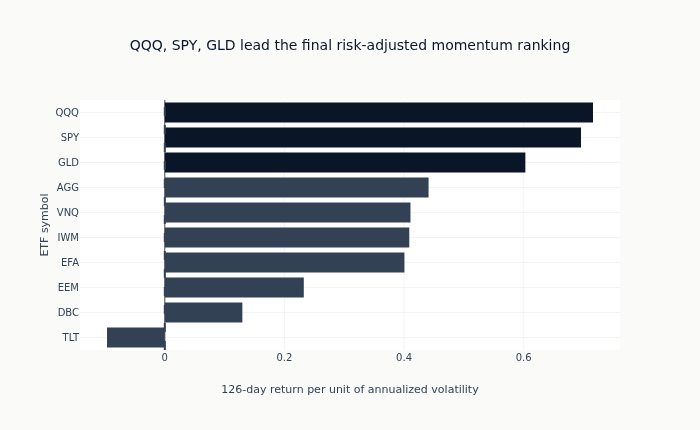

In [11]:
latest_scores = pl.DataFrame({"symbol": ETF_SYMBOLS, "momentum_score": momentum_scores[-1]}).sort(
    "momentum_score", descending=True
)
latest_top = latest_scores.head(TOP_N)["symbol"].to_list()

fig = go.Figure(
    go.Bar(
        x=latest_scores["momentum_score"],
        y=latest_scores["symbol"],
        orientation="h",
        marker_color=[
            COLORS["blue"] if symbol in latest_top else COLORS["neutral"]
            for symbol in latest_scores["symbol"]
        ],
    )
)
fig.update_layout(
    title=f"{', '.join(latest_top)} lead the final risk-adjusted momentum ranking",
    xaxis_title="126-day return per unit of annualized volatility",
    yaxis_title="ETF symbol",
    height=430,
    yaxis=dict(autorange="reversed"),
    showlegend=False,
)
fig.add_vline(x=0, line_dash="dash", line_color=COLORS["neutral"])
fig.show()

## 5. Generate point-in-time target weights

Month-end closes determine the signal. Shifting the target by one bar makes it executable at the
next open. The first bar starts in the defensive allocation because no trailing score exists.

In [12]:
month_end_signal = np.zeros(len(dates), dtype=bool)
for idx in range(len(dates) - 1):
    month_end_signal[idx] = (dates[idx].year, dates[idx].month) != (
        dates[idx + 1].year,
        dates[idx + 1].month,
    )
month_end_signal[-1] = True

defensive_weights = np.zeros(len(ETF_SYMBOLS))
defensive_weights[ETF_SYMBOLS.index("AGG")] = 0.60
defensive_weights[ETF_SYMBOLS.index("TLT")] = 0.40

In [13]:
signal_weights = np.zeros_like(close_prices)
current_target = defensive_weights.copy()

for idx in range(len(dates)):
    if month_end_signal[idx]:
        current_target = defensive_weights.copy()
        valid = np.flatnonzero(np.isfinite(momentum_scores[idx]))
        if idx >= first_valid_idx and regime[idx] and len(valid) >= TOP_N:
            ordered = valid[np.argsort(momentum_scores[idx, valid])]
            selected = ordered[-TOP_N:]
            current_target = np.zeros(len(ETF_SYMBOLS))
            current_target[selected] = 1 / TOP_N
    signal_weights[idx] = current_target

In [14]:
execution_weights = np.vstack([defensive_weights, signal_weights[:-1]])
rebalance_at_open = np.r_[True, month_end_signal[:-1]]

assert np.allclose(execution_weights.sum(axis=1), 1.0)
assert rebalance_at_open.sum() == month_end_signal.sum()
print(f"Monthly next-open rebalances: {rebalance_at_open.sum()}")

Monthly next-open rebalances: 168


## 6. Inspect regime and allocation history

The heatmap keeps ten asset weights legible without assigning ten competing categorical colors.
It also makes defensive months and concentrated momentum rotations easy to distinguish.

In [15]:
fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.06,
    row_heights=[0.30, 0.18, 0.52],
    subplot_titles=["10Y-2Y Treasury spread", "Risk regime", "Next-open target weights"],
)
fig.add_trace(
    go.Scatter(
        x=dates,
        y=yield_curve_slope * 100,
        name="10Y-2Y spread",
        line=dict(color=COLORS["blue"]),
    ),
    row=1,
    col=1,
)
_ = fig.add_hline(
    y=REGIME_THRESHOLD * 100,
    line_dash="dash",
    line_color=COLORS["neutral"],
    row=1,
    col=1,
)

In [16]:
_ = fig.add_trace(
    go.Scatter(
        x=dates,
        y=regime.astype(int),
        name="Risk-on indicator",
        line=dict(color=COLORS["positive"]),
    ),
    row=2,
    col=1,
)
_ = fig.add_trace(
    go.Heatmap(
        x=dates,
        y=ETF_SYMBOLS,
        z=execution_weights.T,
        zmin=0,
        zmax=float(execution_weights.max()),
        colorscale=[[0, COLORS["silver"]], [1, COLORS["blue"]]],
        colorbar=dict(title="Weight", tickformat=".0%"),
        name="Target weight",
    ),
    row=3,
    col=1,
)

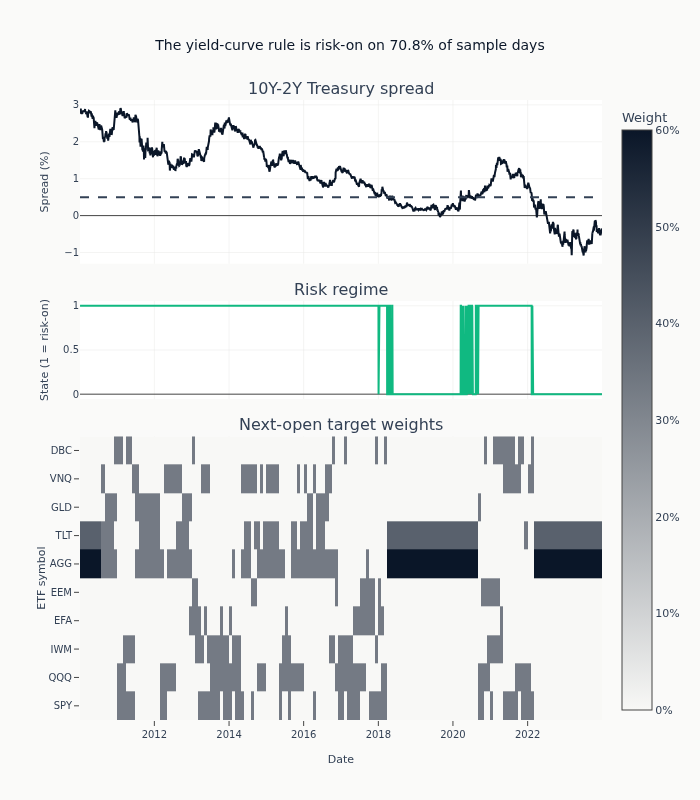

In [17]:
fig.update_layout(
    title=f"The yield-curve rule is risk-on on {risk_on_share:.1%} of sample days",
    height=800,
    showlegend=False,
)
fig.update_yaxes(title_text="Spread (%)", row=1, col=1)
fig.update_yaxes(title_text="State (1 = risk-on)", row=2, col=1)
fig.update_yaxes(title_text="ETF symbol", row=3, col=1)
fig.update_xaxes(title_text="Date", row=3, col=1)
fig.show()

## 7. The fundamental return equation

If weights are executable before period $t$ begins, portfolio return is the inner product

$$
R_{p,t} = \sum_{i=1}^{N} w_{i,t}r_{i,t} = \mathbf{w}_t^\top\mathbf{r}_t.
$$

A close-derived signal cannot use this equation with the same close-to-close return. The
simulator below therefore waits until the next open, then values the resulting holdings at each
close. This explicit event order is the protection against same-bar look-ahead.

In [18]:
toy_weights = np.array([0.60, 0.40])
toy_asset_returns = np.array([0.01, -0.0025])
toy_portfolio_return = float(toy_weights @ toy_asset_returns)
print(f"Toy portfolio return: {toy_portfolio_return:.3%}")

Toy portfolio return: 0.500%


## 8. Simulate next-open fills with a cash constraint

On every scheduled rebalance, the simulator sells first, deducts fees, and then scales purchases
to the remaining cash. End-of-day equity is marked at the close. This ordering prevents the fee
financing and negative-cash behavior that a simultaneous full-notional rebalance can introduce.

In [19]:
def simulate_portfolio(
    opens: np.ndarray,
    closes: np.ndarray,
    target_weights: np.ndarray,
    rebalance_mask: np.ndarray,
    initial_cash: float,
    fee_rate: float,
) -> dict[str, np.ndarray]:
    """Simulate long-only next-open rebalancing with proportional fees."""
    n_bars, n_assets = closes.shape
    holdings = np.zeros(n_assets)
    cash = initial_cash
    equity = np.zeros(n_bars)
    cash_path = np.zeros(n_bars)
    for idx in range(n_bars):
        if rebalance_mask[idx]:
            open_values = holdings * opens[idx]
            open_equity = cash + open_values.sum()
            target_values = target_weights[idx] * open_equity
            sells = np.maximum(open_values - target_values, 0.0)
            holdings -= sells / opens[idx]
            cash += sells.sum() * (1 - fee_rate)
            remaining_values = holdings * opens[idx]
            requested_buys = np.maximum(target_values - remaining_values, 0.0)
            required_cash = requested_buys.sum() * (1 + fee_rate)
            buy_scale = min(1.0, cash / required_cash) if required_cash > 0 else 0.0
            executed_buys = requested_buys * buy_scale
            holdings += executed_buys / opens[idx]
            cash -= executed_buys.sum() * (1 + fee_rate)
        if cash < -1e-8:
            raise RuntimeError(f"Cash constraint violated at bar {idx}: {cash}")
        cash = max(cash, 0.0)
        cash_path[idx] = cash
        equity[idx] = cash + float(holdings @ closes[idx])

    return {"equity": equity, "cash": cash_path}

The momentum strategy and benchmark use the same starting capital, fee rate, data window, and
monthly next-open rebalance mask. Only their target-weight rules differ.

In [20]:
strategy_result = simulate_portfolio(
    open_prices,
    close_prices,
    execution_weights,
    rebalance_at_open,
    INITIAL_CASH,
    FEES,
)

benchmark_weights = np.zeros_like(close_prices)
benchmark_weights[:, ETF_SYMBOLS.index("SPY")] = 0.60
benchmark_weights[:, ETF_SYMBOLS.index("AGG")] = 0.40
benchmark_result = simulate_portfolio(
    open_prices,
    close_prices,
    benchmark_weights,
    rebalance_at_open,
    INITIAL_CASH,
    FEES,
)

In [21]:
portfolio_value = strategy_result["equity"]
benchmark_value = benchmark_result["equity"]
portfolio_returns = (
    np.diff(np.r_[INITIAL_CASH, portfolio_value]) / np.r_[INITIAL_CASH, portfolio_value][:-1]
)
benchmark_returns = (
    np.diff(np.r_[INITIAL_CASH, benchmark_value]) / np.r_[INITIAL_CASH, benchmark_value][:-1]
)

assert strategy_result["cash"].min() >= 0
assert benchmark_result["cash"].min() >= 0
print(f"Final momentum value: ${portfolio_value[-1]:,.2f}")
print(f"Final 60/40 value: ${benchmark_value[-1]:,.2f}")
print(f"Minimum cash balance: ${strategy_result['cash'].min():,.2f}")

Final momentum value: $296,749.02
Final 60/40 value: $330,060.47
Minimum cash balance: $0.00


## 9. Compute one internally consistent metric set

Sharpe and Sortino use mean periodic excess return with a zero annual risk-free rate, matching
`PortfolioAnalysis`. CAGR remains a separate growth metric rather than being substituted into the
Sharpe numerator.

In [22]:
def calculate_metrics(returns: np.ndarray, periods_per_year: int = 252) -> dict[str, float]:
    """Calculate growth, risk, and risk-adjusted performance metrics."""
    total_return = float(np.prod(1 + returns) - 1)
    annual_return = float((1 + total_return) ** (periods_per_year / len(returns)) - 1)
    annual_vol = float(np.std(returns, ddof=1) * np.sqrt(periods_per_year))
    cumulative = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(np.r_[1.0, cumulative])[1:]
    max_dd = float(np.min(cumulative / running_max - 1))

    return {
        "Total Return (%)": total_return * 100,
        "CAGR (%)": annual_return * 100,
        "Annual Volatility (%)": annual_vol * 100,
        "Sharpe Ratio": float(sharpe_ratio(returns, periods_per_year=periods_per_year)),
        "Sortino Ratio": float(sortino_ratio(returns, periods_per_year=periods_per_year)),
        "Max Drawdown (%)": max_dd * 100,
        "Calmar Ratio": annual_return / abs(max_dd) if max_dd else np.nan,
    }

In [23]:
strategy_metrics = calculate_metrics(portfolio_returns)
benchmark_metrics = calculate_metrics(benchmark_returns)
comparison = pl.DataFrame(
    [
        {"portfolio": "ETF Momentum", **strategy_metrics},
        {"portfolio": "60/40 Benchmark", **benchmark_metrics},
    ]
)
comparison

portfolio,Total Return (%),CAGR (%),Annual Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio
str,f64,f64,f64,f64,f64,f64,f64
"""ETF Momentum""",196.749024,8.093499,11.336335,0.743407,0.699163,-31.342872,0.258225
"""60/40 Benchmark""",230.060471,8.919465,10.449564,0.870146,0.809196,-21.602044,0.412899


## 10. Evaluate the pre-specified term sheet

The criteria are decision rules, not tuned cutoffs. A weak baseline remains useful when its
implementation is auditable and later strategies must beat it on identical assumptions.

In [24]:
criteria = pl.DataFrame(
    {
        "criterion": ["Sharpe ratio", "Absolute max drawdown", "Total return vs 60/40"],
        "observed": [
            strategy_metrics["Sharpe Ratio"],
            abs(strategy_metrics["Max Drawdown (%)"]) / 100,
            strategy_metrics["Total Return (%)"] / 100,
        ],
        "required": [0.5, 0.25, benchmark_metrics["Total Return (%)"] / 100],
        "passed": [
            strategy_metrics["Sharpe Ratio"] > 0.5,
            abs(strategy_metrics["Max Drawdown (%)"]) < 25,
            strategy_metrics["Total Return (%)"] > benchmark_metrics["Total Return (%)"],
        ],
    }
)
criteria

criterion,observed,required,passed
str,f64,f64,bool
"""Sharpe ratio""",0.743407,0.5,true
"""Absolute max drawdown""",0.313429,0.25,false
"""Total return vs 60/40""",1.96749,2.300605,false


In [25]:
passed_count = int(criteria["passed"].sum())
failed_count = criteria.height - passed_count
display(
    Markdown(
        f"""**Interpretation.** The baseline passes {passed_count} of {criteria.height} criteria and
        fails {failed_count}. The result is a reference point, not a tuned winner: later strategies
        must improve on the same timing, costs, and benchmark protocol."""
    )
)

**Interpretation.** The baseline passes 1 of 3 criteria and
        fails 2. The result is a reference point, not a tuned winner: later strategies
        must improve on the same timing, costs, and benchmark protocol.

## 11. Compare cumulative performance and drawdowns

Growth of the initial capital answers who finishes ahead; the underwater curve shows the path
risk hidden by an endpoint comparison.

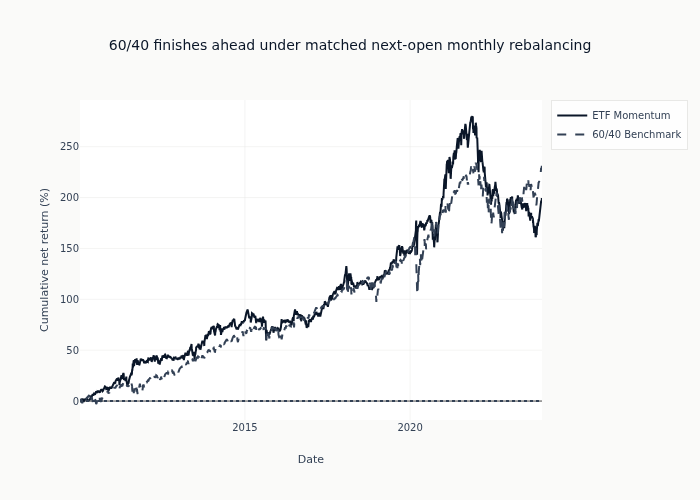

In [26]:
strategy_cum = portfolio_value / INITIAL_CASH - 1
benchmark_cum = benchmark_value / INITIAL_CASH - 1
leader = (
    "60/40 finishes ahead" if benchmark_cum[-1] > strategy_cum[-1] else "Momentum finishes ahead"
)

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=dates,
        y=strategy_cum * 100,
        name="ETF Momentum",
        line=dict(color=COLORS["blue"], width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=dates,
        y=benchmark_cum * 100,
        name="60/40 Benchmark",
        line=dict(color=COLORS["neutral"], dash="dash"),
    )
)
fig.update_layout(
    title=f"{leader} under matched next-open monthly rebalancing",
    xaxis_title="Date",
    yaxis_title="Cumulative net return (%)",
    height=500,
)
fig.add_hline(y=0, line_dash="dot", line_color=COLORS["neutral"])
fig.show()

Drawdown is measured from the running peak, with zero at the top and losses below.

In [27]:
def compute_drawdown(equity: np.ndarray, initial_cash: float) -> np.ndarray:
    """Return percentage drawdown from the running portfolio peak."""
    running_max = np.maximum.accumulate(np.r_[initial_cash, equity])[1:]
    return equity / running_max - 1

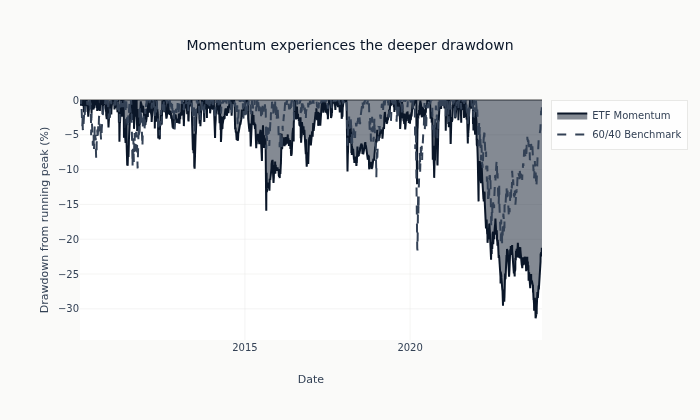

In [28]:
strategy_dd = compute_drawdown(portfolio_value, INITIAL_CASH)
benchmark_dd = compute_drawdown(benchmark_value, INITIAL_CASH)
deeper = (
    "Momentum experiences the deeper drawdown"
    if strategy_dd.min() < benchmark_dd.min()
    else "60/40 experiences the deeper drawdown"
)

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=dates,
        y=strategy_dd * 100,
        name="ETF Momentum",
        fill="tozeroy",
        line=dict(color=COLORS["blue"]),
    )
)
fig.add_trace(
    go.Scatter(
        x=dates,
        y=benchmark_dd * 100,
        name="60/40 Benchmark",
        line=dict(color=COLORS["neutral"], dash="dash"),
    )
)
fig.update_layout(
    title=deeper,
    xaxis_title="Date",
    yaxis_title="Drawdown from running peak (%)",
    height=420,
)
fig.update_yaxes(range=[min(strategy_dd.min(), benchmark_dd.min()) * 110, 0])
fig.show()

## 12. Compare performance by contemporaneous regime

This descriptive slice attributes realized strategy returns to the yield-curve state observed on
that day. It does not claim that the state causes the return difference.

In [29]:
risk_on_returns = portfolio_returns[regime]
risk_off_returns = portfolio_returns[~regime]
regime_metrics = pl.DataFrame(
    {
        "regime": ["Risk-on", "Risk-off"],
        "days": [len(risk_on_returns), len(risk_off_returns)],
        "mean_daily_return_bps": [
            risk_on_returns.mean() * 10_000,
            risk_off_returns.mean() * 10_000,
        ],
        "annualized_volatility_pct": [
            risk_on_returns.std(ddof=1) * np.sqrt(252) * 100,
            risk_off_returns.std(ddof=1) * np.sqrt(252) * 100,
        ],
    }
)
regime_metrics

regime,days,mean_daily_return_bps,annualized_volatility_pct
str,i64,f64,f64
"""Risk-on""",2495,3.992404,11.726092
"""Risk-off""",1027,1.769621,10.329553


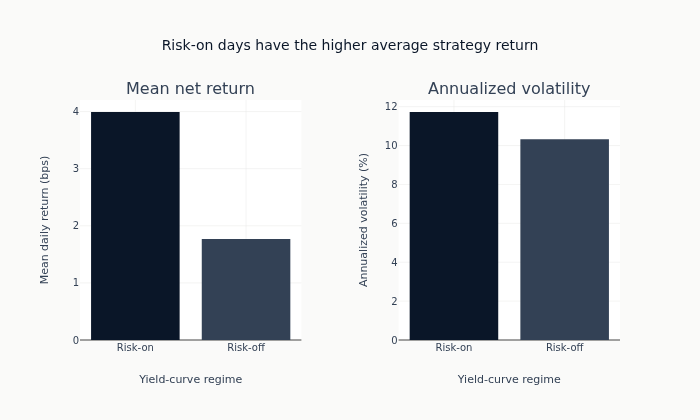

In [30]:
higher_mean = regime_metrics.sort("mean_daily_return_bps", descending=True)["regime"][0]
fig = make_subplots(
    rows=1,
    cols=2,
    horizontal_spacing=0.18,
    subplot_titles=["Mean net return", "Annualized volatility"],
)
fig.add_trace(
    go.Bar(
        x=regime_metrics["regime"],
        y=regime_metrics["mean_daily_return_bps"],
        marker_color=[COLORS["blue"], COLORS["neutral"]],
        showlegend=False,
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Bar(
        x=regime_metrics["regime"],
        y=regime_metrics["annualized_volatility_pct"],
        marker_color=[COLORS["blue"], COLORS["neutral"]],
        showlegend=False,
    ),
    row=1,
    col=2,
)
fig.update_layout(
    title=f"{higher_mean} days have the higher average strategy return",
    height=420,
)
fig.update_yaxes(title_text="Mean daily return (bps)", row=1, col=1)
fig.update_yaxes(title_text="Annualized volatility (%)", row=1, col=2)
fig.update_xaxes(title_text="Yield-curve regime", row=1, col=1)
fig.update_xaxes(title_text="Yield-curve regime", row=1, col=2)
fig.show()

## 13. Reconcile with `ml4t-diagnostic`

The library receives the same daily return arrays and dates. Its headline Sharpe, Sortino, CAGR,
volatility, and drawdown should agree with the table above up to display precision.

In [31]:
analysis = PortfolioAnalysis(
    returns=portfolio_returns,
    benchmark=benchmark_returns,
    dates=dates,
    periods_per_year=252,
)
diagnostic_metrics = analysis.compute_summary_stats()

assert np.isclose(diagnostic_metrics.sharpe_ratio, strategy_metrics["Sharpe Ratio"])
assert np.isclose(diagnostic_metrics.sortino_ratio, strategy_metrics["Sortino Ratio"])
assert np.isclose(diagnostic_metrics.max_drawdown * 100, strategy_metrics["Max Drawdown (%)"])
print(diagnostic_metrics.summary())

Portfolio Performance Summary

Returns
------------------------------
  Total Return:           196.75%
  Annual Return:            8.09%
  Annual Volatility:       11.34%

Risk-Adjusted Returns
------------------------------
  Sharpe Ratio:             0.743
  Sortino Ratio:            0.699
  Calmar Ratio:             0.258
  Omega Ratio:              1.139
  Tail Ratio:               0.994

Risk Metrics
------------------------------
  Max Drawdown:           -31.34%
  VaR (95%):               -1.12%
  CVaR (95%):              -1.72%

Distribution
------------------------------
  Skewness:                -0.457
  Kurtosis:                 3.860
  Stability (R²):           0.876

Win/Loss
------------------------------
  Win Rate:                54.83%
  Profit Factor:             1.14
  Avg Win:                  0.50%
  Avg Loss:                -0.53%

Benchmark Comparison
------------------------------
  Alpha (annual):           5.23%
  Beta:                     0.351
  Informatio

In [32]:
display(
    Markdown(
        f"""## Key takeaways

1. **Event order is part of the model.** Month-end close information becomes tradable at the next
   open; the simulator never applies a signal to a return that began before the signal existed.
2. **The 60/40 benchmark is stronger in this sample.** Momentum's net Sharpe is
   {strategy_metrics["Sharpe Ratio"]:.2f} versus {benchmark_metrics["Sharpe Ratio"]:.2f}, and its
   maximum drawdown is {strategy_metrics["Max Drawdown (%)"]:.1f}% versus
   {benchmark_metrics["Max Drawdown (%)"]:.1f}%.
3. **Cash and costs are explicit.** The simulator rebalances both portfolios monthly, deducts
   {FEES * 10_000:.0f} bps per traded dollar, and maintains a nonnegative cash balance.
4. **The result is descriptive, not a holdout claim.** This fixed-rule teaching backtest provides
   an auditable baseline that later models must beat under the same protocol.

**Next:** `03_single_asset_vectorbt` and `04_single_asset_ml4t_backtest` implement a common RSI rule
in two engines. `06_framework_parity` then isolates protocol differences. See Section 16.4 for the
baseline's role as a yardstick."""
    )
)

## Key takeaways

1. **Event order is part of the model.** Month-end close information becomes tradable at the next
   open; the simulator never applies a signal to a return that began before the signal existed.
2. **The 60/40 benchmark is stronger in this sample.** Momentum's net Sharpe is
   0.74 versus 0.87, and its
   maximum drawdown is -31.3% versus
   -21.6%.
3. **Cash and costs are explicit.** The simulator rebalances both portfolios monthly, deducts
   5 bps per traded dollar, and maintains a nonnegative cash balance.
4. **The result is descriptive, not a holdout claim.** This fixed-rule teaching backtest provides
   an auditable baseline that later models must beat under the same protocol.

**Next:** `03_single_asset_vectorbt` and `04_single_asset_ml4t_backtest` implement a common RSI rule
in two engines. `06_framework_parity` then isolates protocol differences. See Section 16.4 for the
baseline's role as a yardstick.